In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("MHE_21C.CSV", header=4)

print("Raw shape:", df.shape)
df.head()

Raw shape: (579, 125)


,estate,estate_eng,estate_chi,t_pop,pop_m,pop_f,sr,age_1,age_2,age_3,...,dhi_sb_e1,dhi_sb_e2,dhi_sb_e3,dhi_sb_e4,ma_econhh,dhm_loan,dhm_lr,dm_r,dmr_ir,fa_m
0,60047,Aberdeen Centre,香港仔中心,8353.0,3579.0,4774.0,750.0,1000.0,527.0,2375.0,...,95,192,620.0,1341,47170.0,11000,20.9,13000,12.5,42.0
1,60050,Aegean Coast,愛琴海岸,4182.0,1882.0,2300.0,818.0,520.0,275.0,1004.0,...,25,170,285.0,751,49540.0,11500,21.2,15000,41,58.0
2,20001,Affluence Garden,澤豐花園,5893.0,2931.0,2962.0,990.0,543.0,290.0,1735.0,...,12,187,817.0,746,37110.0,8000,21.1,10500,27.6,45.0
3,20002,Aldrich Garden,愛蝶灣,8644.0,3966.0,4678.0,848.0,715.0,1101.0,1642.0,...,80,209,973.0,1231,38720.0,6400,15.4,**,**,55.0
4,60056,Allway Gardens,荃威花園,8732.0,4047.0,4685.0,864.0,990.0,481.0,2410.0,...,78,268,715.0,1464,42070.0,12000,21.4,13000,32.4,45.0


In [2]:
df = df.dropna(axis=1, how="all")
df = df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed", na=False)]
df

,estate,estate_eng,estate_chi,t_pop,pop_m,pop_f,sr,age_1,age_2,age_3,...,dhi_sb_e1,dhi_sb_e2,dhi_sb_e3,dhi_sb_e4,ma_econhh,dhm_loan,dhm_lr,dm_r,dmr_ir,fa_m
0,60047,Aberdeen Centre,香港仔中心,8353.0,3579.0,4774.0,750.0,1000.0,527.0,2375.0,...,95,192,620.0,1341,47170.0,11000,20.9,13000,12.5,42.0
1,60050,Aegean Coast,愛琴海岸,4182.0,1882.0,2300.0,818.0,520.0,275.0,1004.0,...,25,170,285.0,751,49540.0,11500,21.2,15000,41,58.0
2,20001,Affluence Garden,澤豐花園,5893.0,2931.0,2962.0,990.0,543.0,290.0,1735.0,...,12,187,817.0,746,37110.0,8000,21.1,10500,27.6,45.0
3,20002,Aldrich Garden,愛蝶灣,8644.0,3966.0,4678.0,848.0,715.0,1101.0,1642.0,...,80,209,973.0,1231,38720.0,6400,15.4,**,**,55.0
4,60056,Allway Gardens,荃威花園,8732.0,4047.0,4685.0,864.0,990.0,481.0,2410.0,...,78,268,715.0,1464,42070.0,12000,21.4,13000,32.4,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
574,NaN,（查詢電話：3428 2744； 查詢電郵：census2021@censtatd.gov.hk）,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
575,Source:,"2021 Population Census, Census and Statistics ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
576,NaN,(Enquiry telephone no.: 3428 2744; Enquiry e-m...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
577,如欲獲取更多2021年人口普查的地區統計數字，請瀏覽2021年人口普查主題網站內的「地區概覽...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
key_cols = ["age_2", "age_3"] 
df = df.dropna(subset=key_cols)
df

,estate,estate_eng,estate_chi,t_pop,pop_m,pop_f,sr,age_1,age_2,age_3,...,dhi_sb_e1,dhi_sb_e2,dhi_sb_e3,dhi_sb_e4,ma_econhh,dhm_loan,dhm_lr,dm_r,dmr_ir,fa_m
0,60047,Aberdeen Centre,香港仔中心,8353.0,3579.0,4774.0,750.0,1000.0,527.0,2375.0,...,95,192,620.0,1341,47170.0,11000,20.9,13000,12.5,42.0
1,60050,Aegean Coast,愛琴海岸,4182.0,1882.0,2300.0,818.0,520.0,275.0,1004.0,...,25,170,285.0,751,49540.0,11500,21.2,15000,41,58.0
2,20001,Affluence Garden,澤豐花園,5893.0,2931.0,2962.0,990.0,543.0,290.0,1735.0,...,12,187,817.0,746,37110.0,8000,21.1,10500,27.6,45.0
3,20002,Aldrich Garden,愛蝶灣,8644.0,3966.0,4678.0,848.0,715.0,1101.0,1642.0,...,80,209,973.0,1231,38720.0,6400,15.4,**,**,55.0
4,60056,Allway Gardens,荃威花園,8732.0,4047.0,4685.0,864.0,990.0,481.0,2410.0,...,78,268,715.0,1464,42070.0,12000,21.4,13000,32.4,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,20168,Yuk Ming Court,煜明苑,5090.0,2403.0,2687.0,894.0,359.0,493.0,1271.0,...,56,70,540.0,829,42270.0,12000,28.5,**,**,50.0
537,20169,Yuk Po Court,旭埔苑,3015.0,1344.0,1671.0,804.0,207.0,135.0,686.0,...,38,163,327.0,378,35190.0,7810,20.2,10000,39.9,51.0
538,20174,Yung Ming Court,雍明苑,3360.0,1609.0,1751.0,919.0,383.0,231.0,1234.0,...,47,110,428.0,528,38000.0,11600,30.9,**,**,35.0
539,10204,Yung Shing Court,雍盛苑,7434.0,3451.0,3983.0,866.0,629.0,682.0,2506.0,...,273,307,815.0,581,31070.0,3800,10.3,2870,10.8,43.0


In [ ]:
df = df[~df["estate_eng"].str.contains("total|overall|hong kong", case=False, na=False)]

from pathlib import Path
closed_path = Path("closed_estates.csv")
if closed_path.exists():
    closed_df = pd.read_csv(closed_path)
    closed_names = set(closed_df["estate_eng"].astype(str).str.strip())
    before = len(df)
    df = df[~df["estate_eng"].isin(closed_names)].copy()
    print("Closed estates removed:", before - len(df))
else:
    print("closed_estates.csv not found; skipping closed-estate filter")

df

,estate,estate_eng,estate_chi,t_pop,pop_m,pop_f,sr,age_1,age_2,age_3,...,dhi_sb_e1,dhi_sb_e2,dhi_sb_e3,dhi_sb_e4,ma_econhh,dhm_loan,dhm_lr,dm_r,dmr_ir,fa_m
0,60047,Aberdeen Centre,香港仔中心,8353.0,3579.0,4774.0,750.0,1000.0,527.0,2375.0,...,95,192,620.0,1341,47170.0,11000,20.9,13000,12.5,42.0
1,60050,Aegean Coast,愛琴海岸,4182.0,1882.0,2300.0,818.0,520.0,275.0,1004.0,...,25,170,285.0,751,49540.0,11500,21.2,15000,41,58.0
2,20001,Affluence Garden,澤豐花園,5893.0,2931.0,2962.0,990.0,543.0,290.0,1735.0,...,12,187,817.0,746,37110.0,8000,21.1,10500,27.6,45.0
3,20002,Aldrich Garden,愛蝶灣,8644.0,3966.0,4678.0,848.0,715.0,1101.0,1642.0,...,80,209,973.0,1231,38720.0,6400,15.4,**,**,55.0
4,60056,Allway Gardens,荃威花園,8732.0,4047.0,4685.0,864.0,990.0,481.0,2410.0,...,78,268,715.0,1464,42070.0,12000,21.4,13000,32.4,45.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,20167,Yuet Wu Villa,悅湖山莊,10760.0,5190.0,5570.0,932.0,727.0,908.0,2610.0,...,216,451,988.0,1440,37680.0,7980,21,12000,21.5,55.0
536,20168,Yuk Ming Court,煜明苑,5090.0,2403.0,2687.0,894.0,359.0,493.0,1271.0,...,56,70,540.0,829,42270.0,12000,28.5,**,**,50.0
537,20169,Yuk Po Court,旭埔苑,3015.0,1344.0,1671.0,804.0,207.0,135.0,686.0,...,38,163,327.0,378,35190.0,7810,20.2,10000,39.9,51.0
538,20174,Yung Ming Court,雍明苑,3360.0,1609.0,1751.0,919.0,383.0,231.0,1234.0,...,47,110,428.0,528,38000.0,11600,30.9,**,**,35.0


In [6]:
import pandas as pd
import ssl
import certifi
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

In [7]:
ssl_context = ssl.create_default_context(cafile=certifi.where())
geolocator = Nominatim(user_agent="hk-elderly-matching-app", ssl_context=ssl_context)
geocode = RateLimiter(
    geolocator.geocode,
    min_delay_seconds=1,
    max_retries=2,
    error_wait_seconds=2,
    swallow_exceptions=False
 )

In [7]:
# Build address columns first (English + Chinese fallback)
if "estate_eng" not in df.columns:
    raise ValueError("Column 'estate_eng' not found. Check your header row.")

if "estate_chi" not in df.columns:
    df["estate_chi"] = ""

df["full_address"] = (
    df["estate_eng"].fillna("").astype(str).str.strip() + ", Hong Kong"
)
df["full_address_alt"] = (
    df["estate_chi"].fillna("").astype(str).str.strip() + ", Hong Kong"
)

# Persist cache across runs so you can execute in batches
CACHE_PATH = "geocode_cache.csv"
BATCH_SIZE = 80  # increased batch size to improve coverage per run
RETRY_NONE = True  # retry previously unresolved entries after SSL fix

try:
    cache_df = pd.read_csv(CACHE_PATH)
    cache = dict(zip(cache_df["full_address"], zip(cache_df["latitude"], cache_df["longitude"])))
except FileNotFoundError:
    cache = {}

# Map EN query -> ZH fallback query
alt_lookup = dict(zip(df["full_address"], df["full_address_alt"]))

def fetch_or_geocode(query):
    if not query or query == "Hong Kong":
        return (None, None)
    if query in cache and not (RETRY_NONE and pd.isna(cache[query][0])):
        return cache[query]
    try:
        loc = geocode(query)
        if loc is None:
            result = (None, None)
        else:
            result = (loc.latitude, loc.longitude)
        cache[query] = result
        return result
    except Exception as e:
        print(f"Geocode error for {query}: {type(e).__name__}")
        cache[query] = (None, None)
        return (None, None)

def geocode_address(addr):
    # Try English first, then Chinese fallback for better hit rate.
    candidates = [addr]
    alt = alt_lookup.get(addr, "")
    if isinstance(alt, str) and alt.strip() and alt != "Hong Kong":
        candidates.append(alt)

    for query in candidates:
        latlon = fetch_or_geocode(query)
        if not pd.isna(latlon[0]):
            cache[addr] = latlon
            return latlon

    cache[addr] = (None, None)
    return (None, None)

unique_addrs = pd.Series(df["full_address"].dropna().unique())

if RETRY_NONE:
    pending = [a for a in unique_addrs if (a not in cache) or pd.isna(cache[a][0])]
else:
    pending = [a for a in unique_addrs if a not in cache]

for addr in pending[:BATCH_SIZE]:
    geocode_address(addr)

cache_out = pd.DataFrame(
    [(k, v[0], v[1]) for k, v in cache.items()],
    columns=["full_address", "latitude", "longitude"]
)
cache_out.to_csv(CACHE_PATH, index=False)

df = df.drop(columns=[c for c in ["latitude", "longitude"] if c in df.columns])
df = df.merge(cache_out, on="full_address", how="left")

print("Unique addresses:", len(unique_addrs))
print("Cached addresses:", len(cache))
print("Pending addresses:", max(0, len(pending) - BATCH_SIZE))
print("Rows:", len(df))
print("Geocoded rows:", int(df["latitude"].notna().sum()))
print("Missing rows:", int(df["latitude"].isna().sum()))

df[["estate_eng", "estate_chi", "full_address", "latitude", "longitude"]].head(10)

Unique addresses: 538
Cached addresses: 549
Pending addresses: 0
Rows: 538
Geocoded rows: 534
Missing rows: 4


,estate_eng,estate_chi,full_address,latitude,longitude
0,Aberdeen Centre,香港仔中心,"Aberdeen Centre, Hong Kong",22.248480,114.154159
1,Aegean Coast,愛琴海岸,"Aegean Coast, Hong Kong",22.372492,113.994873
2,Affluence Garden,澤豐花園,"Affluence Garden, Hong Kong",22.403428,113.975147
3,Aldrich Garden,愛蝶灣,"Aldrich Garden, Hong Kong",22.280552,114.228798
4,Allway Gardens,荃威花園,"Allway Gardens, Hong Kong",22.376980,114.104218
5,Amoy Gardens,淘大花園,"Amoy Gardens, Hong Kong",22.324627,114.216459
6,Ap Lei Chau Estate,鴨脷洲邨,"Ap Lei Chau Estate, Hong Kong",22.244514,114.149340
7,Aqua Marine,碧海藍天,"Aqua Marine, Hong Kong",22.332894,114.148365
8,Avon Park,碧湖花園,"Avon Park, Hong Kong",22.487672,114.142910
9,Baguio Villa,碧瑤灣,"Baguio Villa, Hong Kong",22.262271,114.133722


## Manual Geocode Overrides (For Remaining Missing Estates)

If some estates are still missing coordinates, you can fill them manually:
1. Open `manual_geocode_overrides.csv`.
2. Fill `latitude` and `longitude` for missing estates.
3. Re-run the next cell to merge overrides into `df`.

This is useful for estates that public geocoding cannot resolve reliably.

In [9]:
# Export missing estates for manual fill, then merge manual overrides if provided
import os

missing = df[df["latitude"].isna()][["estate_eng", "estate_chi", "full_address"]].drop_duplicates().copy()
missing["latitude"] = pd.NA
missing["longitude"] = pd.NA

MANUAL_PATH = "manual_geocode_overrides.csv"

# Create template once; do not overwrite user-entered manual coordinates on rerun.
if not os.path.exists(MANUAL_PATH):
    missing.to_csv(MANUAL_PATH, index=False)
    print(f"Created manual template: {MANUAL_PATH} ({len(missing)} rows)")
else:
    print(f"Using existing manual file: {MANUAL_PATH}")

# If user has filled manual coordinates, apply them immediately.
manual = pd.read_csv(MANUAL_PATH)
for c in ["latitude", "longitude"]:
    manual[c] = pd.to_numeric(manual[c], errors="coerce")

manual_valid = manual.dropna(subset=["full_address", "latitude", "longitude"]).copy()
print(f"Manual rows with valid lat/lon: {len(manual_valid)}")

if len(manual_valid) > 0:
    # Fill missing coordinates only; keep existing geocoded values intact.
    if "latitude" not in df.columns:
        df["latitude"] = pd.NA
    if "longitude" not in df.columns:
        df["longitude"] = pd.NA

    df = df.merge(
        manual_valid[["full_address", "latitude", "longitude"]],
        on="full_address",
        how="left",
        suffixes=("", "_manual")
    )

    if "latitude_manual" in df.columns:
        df["latitude"] = df["latitude"].fillna(df["latitude_manual"])
        df["longitude"] = df["longitude"].fillna(df["longitude_manual"])
        df = df.drop(columns=["latitude_manual", "longitude_manual"])

print("Geocoded rows after manual merge:", int(df["latitude"].notna().sum()))
print("Missing rows after manual merge:", int(df["latitude"].isna().sum()))

KeyError: 'latitude'

In [9]:
df.to_csv("MHE_21C_with_latlon_updated.csv", index=False)

In [10]:
df = pd.read_csv("MHE_21C_with_latlon_updated.csv")

## Map-Facing Cluster View (Geo-Only, Small k)

This view is for planning analytics only.
Your app's core remains 1-to-1 volunteer matching.

Settings in this cell:
- Use only longitude/latitude for contiguous map zones
- Keep k between 4 and 6 for current data coverage

Usable estates with geo coords: 532
k used for map-facing clusters: 6


/var/folders/pv/1yjnf_nn72q770btqnpp923r0000gn/T/ipykernel_21776/1561267938.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Set2', k_geo_map)


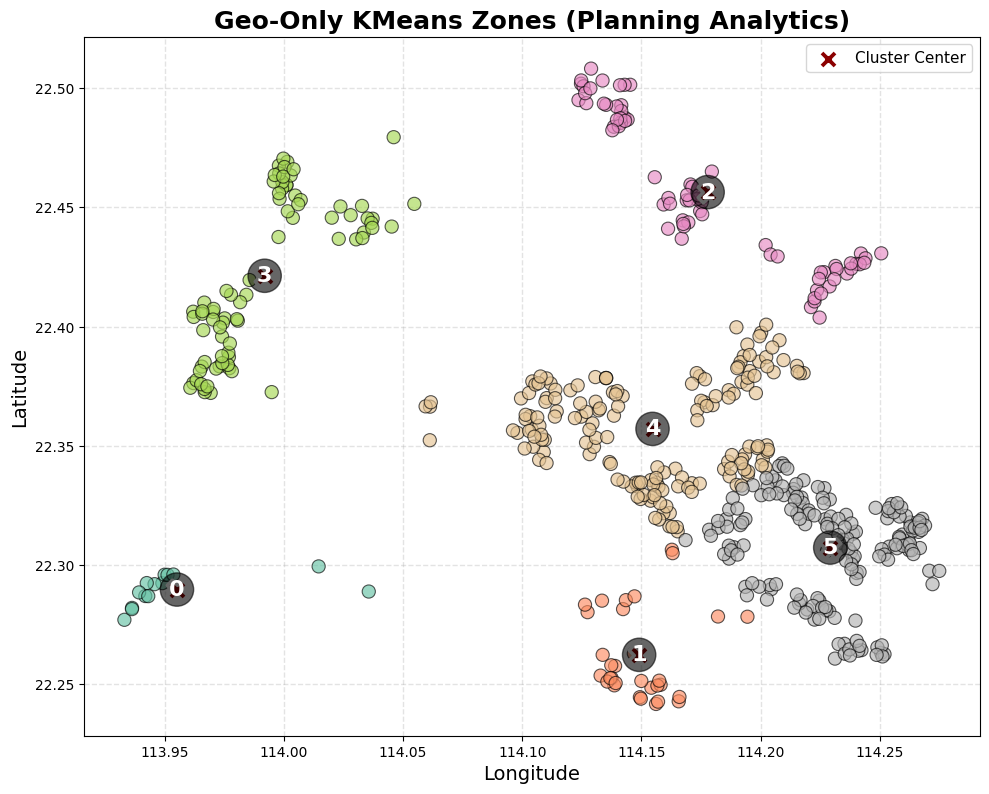

,geo_cluster,estates,avg_age_5,avg_age_2
5,5,170,1861.141176,712.529412
4,4,165,1991.727273,742.763636
3,3,79,1559.126582,793.708861
2,2,73,1398.178082,545.917808
1,1,31,1686.032258,538.129032
0,0,14,1234.142857,876.571429


Saved: cluster_summary_geo_only.csv


In [6]:
kmeans = pd.read_csv("MHE_21C_with_latlon_updated.csv")
kmeans = kmeans[["estate_eng", "longitude", "latitude", "age_5", "age_2"]].copy()
kmeans[["longitude", "latitude", "age_5", "age_2"]] = kmeans[["longitude", "latitude", "age_5", "age_2"]].apply(pd.to_numeric, errors="coerce")
kmeans = kmeans.dropna(subset=["estate_eng", "longitude", "latitude"])

# Remove geographic outliers (longitude/latitude > 3 std from mean)
lon_mean, lon_std = kmeans["longitude"].mean(), kmeans["longitude"].std()
lat_mean, lat_std = kmeans["latitude"].mean(), kmeans["latitude"].std()
mask = (
    (kmeans["longitude"] > lon_mean - 3 * lon_std) & (kmeans["longitude"] < lon_mean + 3 * lon_std)
    & (kmeans["latitude"] > lat_mean - 3 * lat_std) & (kmeans["latitude"] < lat_mean + 3 * lat_std)
)
kmeans = kmeans[mask].copy()

usable_geo_estates = kmeans["estate_eng"].nunique()
k_geo_map = min(6, max(4, usable_geo_estates // 12))

features = StandardScaler().fit_transform(kmeans[["longitude", "latitude"]])
kmeans["geo_cluster"] = KMeans(n_clusters=k_geo_map, random_state=42, n_init=20).fit_predict(features)

print(f"Usable estates with geo coords: {usable_geo_estates}")
print(f"k used for map-facing clusters: {k_geo_map}")

plt.figure(figsize=(10, 8))
# Use a colorblind-friendly palette
import matplotlib.cm as cm
colors = cm.get_cmap('Set2', k_geo_map)

scatter = plt.scatter(
    kmeans["longitude"],
    kmeans["latitude"],
    c=kmeans["geo_cluster"],
    cmap=colors,
    s=90,
    alpha=0.65,
    edgecolor='black',
    linewidth=0.8,
    zorder=2
)

# Plot cluster centers (already computed by KMeans above)
centers = KMeans(n_clusters=k_geo_map, random_state=42, n_init=20).fit(features).cluster_centers_
centers_unscaled = StandardScaler().fit(kmeans[["longitude", "latitude"]]).inverse_transform(centers)
plt.scatter(
    centers_unscaled[:, 0],
    centers_unscaled[:, 1],
    c='darkred',
    s=220,
    marker='X',
    edgecolor='white',
    linewidth=2.5,
    zorder=3,
    label='Cluster Center'
)

# Add cluster labels at centers
for i, (x, y) in enumerate(centers_unscaled):
    plt.text(x, y, str(i), fontsize=16, fontweight='bold', color='white',
             ha='center', va='center', bbox=dict(facecolor='black', alpha=0.6, boxstyle='circle'), zorder=4)

plt.title("Geo-Only KMeans Zones (Planning Analytics)", fontsize=18, fontweight='bold')
plt.xlabel("Longitude", fontsize=14)
plt.ylabel("Latitude", fontsize=14)
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.35, linestyle='--', linewidth=1)
plt.tight_layout()
plt.legend(loc='best', fontsize=11)
plt.show()

geo_summary = kmeans.groupby("geo_cluster", as_index=False).agg(
    estates=("estate_eng", "count"),
    avg_age_5=("age_5", "mean"),
    avg_age_2=("age_2", "mean"),
).sort_values("estates", ascending=False)

display(geo_summary)
geo_summary.to_csv("cluster_summary_geo_only.csv", index=False)
print("Saved: cluster_summary_geo_only.csv")


## Elderly Concentration by Estate

This section measures elderly concentration directly for each estate:
- `elderly_concentration = age_5 / t_pop`
- shown as a percentage for easy interpretation

Use this for identifying estates where elderly residents make up a larger share of the local population.

Top 15 estates by elderly concentration (% of estate population):


,estate_eng,t_pop,age_5,elderly_concentration_pct
0,Lok Wah South Estate,13258.0,5438.0,41.016745
1,Cho Yiu Chuen,6717.0,2727.0,40.598481
2,Jat Min Chuen,9424.0,3541.0,37.574278
3,Ming Wah Dai Ha,5299.0,1951.0,36.818268
4,Wang Fuk Court,4643.0,1701.0,36.635796
5,Chun Shek Estate,5212.0,1889.0,36.243285
6,Lok Man Sun Chuen,8696.0,3133.0,36.028059
7,Lai Kok Estate,6200.0,2227.0,35.919355
8,Lai Tak Tsuen,6211.0,2199.0,35.404927
9,Hing Tin Estate,6467.0,2285.0,35.333230


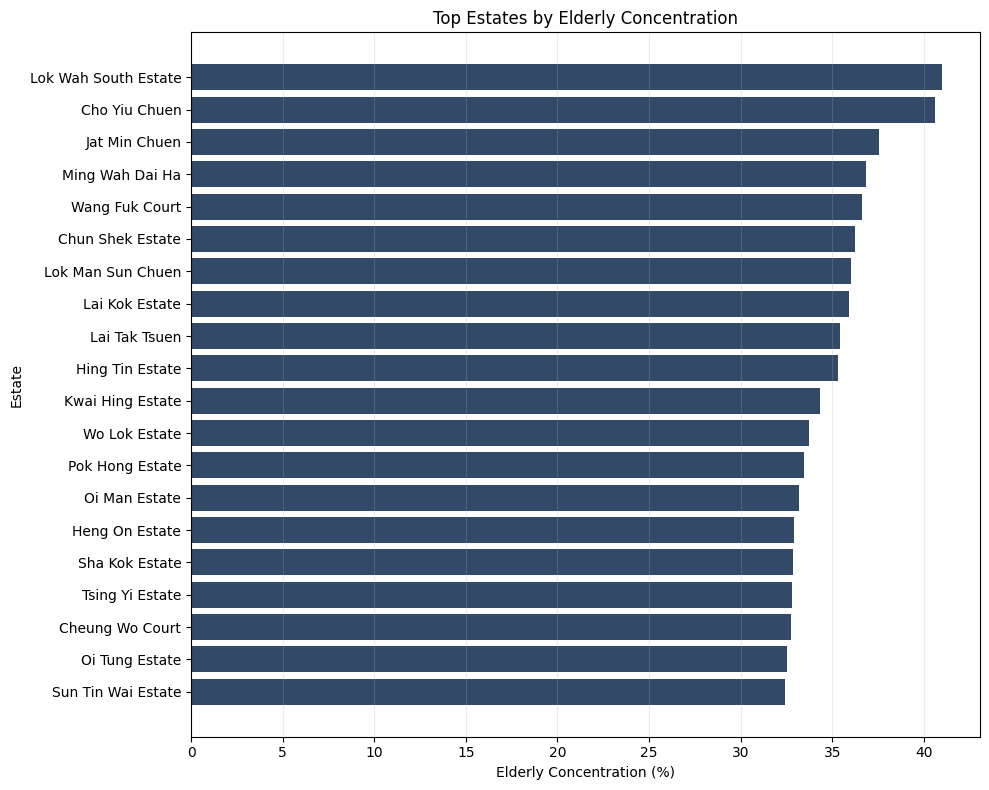

Saved: estate_elderly_concentration.csv


In [9]:
conc = pd.read_csv("MHE_21C_with_latlon_updated.csv")
conc = conc[["estate_eng", "t_pop", "age_5"]].copy()

for c in ["t_pop", "age_5"]:
    conc[c] = pd.to_numeric(conc[c], errors="coerce")

conc = conc.dropna(subset=["estate_eng", "t_pop", "age_5"])
conc = conc[conc["t_pop"] > 0]

conc["elderly_concentration"] = conc["age_5"] / conc["t_pop"]
conc["elderly_concentration_pct"] = 100 * conc["elderly_concentration"]

conc = conc.sort_values("elderly_concentration", ascending=False).reset_index(drop=True)

print("Top 15 estates by elderly concentration (% of estate population):")
display(conc[["estate_eng", "t_pop", "age_5", "elderly_concentration_pct"]].head(15))

plot_conc = conc.head(20).sort_values("elderly_concentration_pct", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_conc["estate_eng"], plot_conc["elderly_concentration_pct"], color="#1d3557", alpha=0.9)
plt.title("Top Estates by Elderly Concentration")
plt.xlabel("Elderly Concentration (%)")
plt.ylabel("Estate")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

conc.to_csv("estate_elderly_concentration.csv", index=False)
print("Saved: estate_elderly_concentration.csv")

In [36]:
# List estates whose coordinates are still missing
missing_estates = (
    df[df["latitude"].isna()][["estate_eng", "estate_chi", "full_address"]]
    .drop_duplicates()
    .sort_values("estate_eng")
    .reset_index(drop=True)
)

print(f"Missing coordinate estates: {len(missing_estates)}")
display(missing_estates.head(30))

missing_estates.to_csv("missing_estates_coordinates.csv", index=False)
print("Saved: missing_estates_coordinates.csv")

Missing coordinate estates: 34


,estate_eng,estate_chi,full_address
0,LOHAS Park - Malibu,日出康城－Malibu,"LOHAS Park - Malibu, Hong Kong"
1,"LOHAS Park - The Capitol, Le Prestige, Le Prim...",日出康城－首都、領都、領峰、領凱、緻藍天,"LOHAS Park - The Capitol, Le Prestige, Le Prim..."
2,Tin Yiu (1) Estate,天耀一邨,"Tin Yiu (1) Estate, Hong Kong"
3,Tin Yiu (2) Estate,天耀二邨,"Tin Yiu (2) Estate, Hong Kong"
4,Yan On Estate,欣安邨,"Yan On Estate, Hong Kong"
5,Yan Shing Court,欣盛苑,"Yan Shing Court, Hong Kong"
6,Yan Tin Estate,欣田邨,"Yan Tin Estate, Hong Kong"
7,Yat Nga Court,逸雅苑,"Yat Nga Court, Hong Kong"
8,Yat Tung (1) Estate,逸東（１）邨,"Yat Tung (1) Estate, Hong Kong"
9,Yat Tung (2) Estate,逸東（２）邨,"Yat Tung (2) Estate, Hong Kong"


Saved: missing_estates_coordinates.csv


In [35]:
# Second-pass online lookup for missing estates using Chinese names
second_pass = missing_estates.copy()
second_pass = second_pass[second_pass["estate_chi"].notna()].copy()
second_pass["estate_chi"] = second_pass["estate_chi"].astype(str).str.strip()
second_pass = second_pass[second_pass["estate_chi"] != ""]

SECOND_PASS_BATCH = 120  # rerun this cell to continue
hits = []

for _, r in second_pass.head(SECOND_PASS_BATCH).iterrows():
    chi = r["estate_chi"]
    eng_addr = r["full_address"]

    # Try a few Chinese query forms for better hit rate.
    queries = [
        f"{chi}, Hong Kong",
        f"{chi} 香港",
        chi,
    ]

    latlon = (None, None)
    for q in queries:
        try:
            loc = geocode(q)
            if loc is not None:
                latlon = (loc.latitude, loc.longitude)
                break
        except Exception:
            continue

    if latlon[0] is not None:
        hits.append((eng_addr, latlon[0], latlon[1], chi))

hits_df = pd.DataFrame(hits, columns=["full_address", "latitude", "longitude", "estate_chi"])
print(f"Chinese second-pass hits this run: {len(hits_df)}")

if len(hits_df) > 0:
    # Fill only missing lat/lon; do not overwrite existing coordinates.
    df = df.merge(
        hits_df[["full_address", "latitude", "longitude"]],
        on="full_address",
        how="left",
        suffixes=("", "_zh")
    )
    df["latitude"] = df["latitude"].fillna(df["latitude_zh"])
    df["longitude"] = df["longitude"].fillna(df["longitude_zh"])
    df = df.drop(columns=["latitude_zh", "longitude_zh"])

    # Update geocode cache with new successes.
    try:
        cache_df = pd.read_csv(CACHE_PATH)
    except FileNotFoundError:
        cache_df = pd.DataFrame(columns=["full_address", "latitude", "longitude"])

    cache_df = pd.concat([
        cache_df,
        hits_df[["full_address", "latitude", "longitude"]]
    ], ignore_index=True)
    cache_df = cache_df.drop_duplicates(subset=["full_address"], keep="last")
    cache_df.to_csv(CACHE_PATH, index=False)

print("Geocoded rows after Chinese second-pass:", int(df["latitude"].notna().sum()))
print("Missing rows after Chinese second-pass:", int(df["latitude"].isna().sum()))

# Save updated file immediately so downstream cells use latest coordinates
df.to_csv("MHE_21C_with_latlon_updated.csv", index=False)
print("Saved: MHE_21C_with_latlon_updated.csv")

RateLimiter caught an error, retrying (0/2 tries). Called with (*('大興邨, Hong Kong',), **{}).
Traceback (most recent call last):
  File "/Users/disha/Elderly App/.venv/lib/python3.14/site-packages/geopy/adapters.py", line 298, in get_text
    page = self.urlopen(req, timeout=timeout)
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/urllib/request.py", line 487, in open
    response = self._open(req, data)
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/urllib/request.py", line 504, in _open
    result = self._call_chain(self.handle_open, protocol, protocol +
                              '_open', req)
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/urllib/request.py", line 464, in _call_chain
    result = func(*args)
  File "/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/urllib/request.py", line 1369, in https_open
    return self.do_open(http.client.HTTPSConnection, req,
           ~~~~~~~~~

Chinese second-pass hits this run: 116
Geocoded rows after Chinese second-pass: 504
Missing rows after Chinese second-pass: 34
Saved: MHE_21C_with_latlon_updated.csv


## Jaccard + Distance Matching Process (Fake Elderly/Youth Data)

This section documents how compatibility scoring is computed for matching.

### 1) Inputs used
Each profile uses:
- `name`
- `district`
- `interests` (semicolon-separated text)
- `longitude`, `latitude`

### 2) Interest similarity (Jaccard)
Interests are normalized (trim + lowercase), converted to sets, and scored using:

$J(A,B)=|A\\cap B|/|A\\cup B|$

- `0` means no overlap
- `1` means identical interest sets

### 3) Geographic distance (Haversine)
Distance between two coordinates is computed in km using Haversine formula, then converted to a proximity score:

$distance\\_score = 1/(1+distance\\_km)$

### 4) Final compatibility score
Final score combines interest similarity and proximity:

$final\\_score = 0.7 * jaccard + 0.3 * distance\\_score$

### 5) Matching direction
For each elderly profile, youth candidates are ranked by `final_score` and top matches are selected. (The same can be done youth->elderly.)

In [3]:
# --- Synthetic youth/elderly profiles aligned to clean estate pool ---
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# Build the same clean estate pool used by geo clustering.
estate_pool = pd.read_csv("MHE_21C_with_latlon_updated.csv")
estate_pool = estate_pool[["estate_eng", "longitude", "latitude"]].copy()
estate_pool[["longitude", "latitude"]] = estate_pool[["longitude", "latitude"]].apply(pd.to_numeric, errors="coerce")
estate_pool = estate_pool.dropna(subset=["estate_eng", "longitude", "latitude"])
estate_pool["estate_eng"] = estate_pool["estate_eng"].astype(str).str.strip()
estate_pool = estate_pool.drop_duplicates(subset=["estate_eng"]).reset_index(drop=True)

# Apply same geo outlier trimming used in clustering so pool matches DBSCAN/KMeans set.
lon_mean, lon_std = estate_pool["longitude"].mean(), estate_pool["longitude"].std()
lat_mean, lat_std = estate_pool["latitude"].mean(), estate_pool["latitude"].std()
mask = (
    (estate_pool["longitude"] > lon_mean - 3 * lon_std)
    & (estate_pool["longitude"] < lon_mean + 3 * lon_std)
    & (estate_pool["latitude"] > lat_mean - 3 * lat_std)
    & (estate_pool["latitude"] < lat_mean + 3 * lat_std)
)
estate_pool = estate_pool[mask].reset_index(drop=True)

estate_names = estate_pool["estate_eng"].tolist()

# Interest pools with partial overlap for realistic matching behavior.
youth_interest_pool = [
    "sports", "music", "gaming", "coding", "volunteering", "movies", "fitness", "photography", "art", "reading"
]
elderly_interest_pool = [
    "walking", "gardening", "reading", "cooking", "music", "mahjong", "calligraphy", "volunteering", "opera", "tai chi"
]


def sample_interests(pool, min_k=3, max_k=5):
    k = int(rng.integers(min_k, max_k + 1))
    return ";".join(rng.choice(pool, size=k, replace=False).tolist())


def make_profiles(group_prefix, n_rows, interest_pool):
    sampled = estate_pool.sample(n=n_rows, replace=True, random_state=42).reset_index(drop=True)
    out = pd.DataFrame({
        "name": [f"{group_prefix}_{i+1:03d}" for i in range(n_rows)],
        "estate_eng": sampled["estate_eng"],
        "longitude": sampled["longitude"],
        "latitude": sampled["latitude"],
        "interests": [sample_interests(interest_pool) for _ in range(n_rows)],
    })
    return out

fake_elderly = make_profiles("elderly", 80, elderly_interest_pool)
fake_youth = make_profiles("youth", 120, youth_interest_pool)

# Hard check: fake profiles must not introduce estates outside clean pool.
clean_set = set(estate_names)
extra_elderly = sorted(set(fake_elderly["estate_eng"]) - clean_set)
extra_youth = sorted(set(fake_youth["estate_eng"]) - clean_set)

print(f"Clean estate pool size: {len(clean_set)}")
print(f"Fake elderly rows: {len(fake_elderly)}, fake youth rows: {len(fake_youth)}")
print(f"Unique estates used (elderly): {fake_elderly['estate_eng'].nunique()}")
print(f"Unique estates used (youth): {fake_youth['estate_eng'].nunique()}")
print(f"Extra estates in fake elderly: {len(extra_elderly)}")
print(f"Extra estates in fake youth: {len(extra_youth)}")

if extra_elderly or extra_youth:
    raise ValueError("Fake profile generation produced estates outside clean pool.")

# Optional exports for downstream matching cells.
fake_elderly.to_csv("fake_elderly_profiles.csv", index=False)
fake_youth.to_csv("fake_youth_profiles.csv", index=False)
print("Saved: fake_elderly_profiles.csv, fake_youth_profiles.csv")

display(fake_elderly.head(5))
display(fake_youth.head(5))

Clean estate pool size: 532
Fake elderly rows: 80, fake youth rows: 120
Unique estates used (elderly): 75
Unique estates used (youth): 107
Extra estates in fake elderly: 0
Extra estates in fake youth: 0
Saved: fake_elderly_profiles.csv, fake_youth_profiles.csv


,name,estate_eng,longitude,latitude,interests
0,elderly_001,Fu Ning Garden,114.267764,22.319337,calligraphy;music;mahjong
1,elderly_002,Tin Yan Estate,113.996162,22.463573,mahjong;walking;gardening
2,elderly_003,Mountain Shore,114.222589,22.410536,calligraphy;music;opera;mahjong;gardening
3,elderly_004,Fu Tung Estate,113.941850,22.286951,volunteering;calligraphy;opera
4,elderly_005,Chuk Yuen South Estate,114.192264,22.344273,volunteering;cooking;walking;reading


,name,estate_eng,longitude,latitude,interests
0,youth_001,Fu Ning Garden,114.267764,22.319337,movies;fitness;art;reading;coding
1,youth_002,Tin Yan Estate,113.996162,22.463573,volunteering;music;movies;photography
2,youth_003,Mountain Shore,114.222589,22.410536,music;photography;gaming
3,youth_004,Fu Tung Estate,113.941850,22.286951,reading;photography;art;volunteering
4,youth_005,Chuk Yuen South Estate,114.192264,22.344273,movies;fitness;volunteering;sports


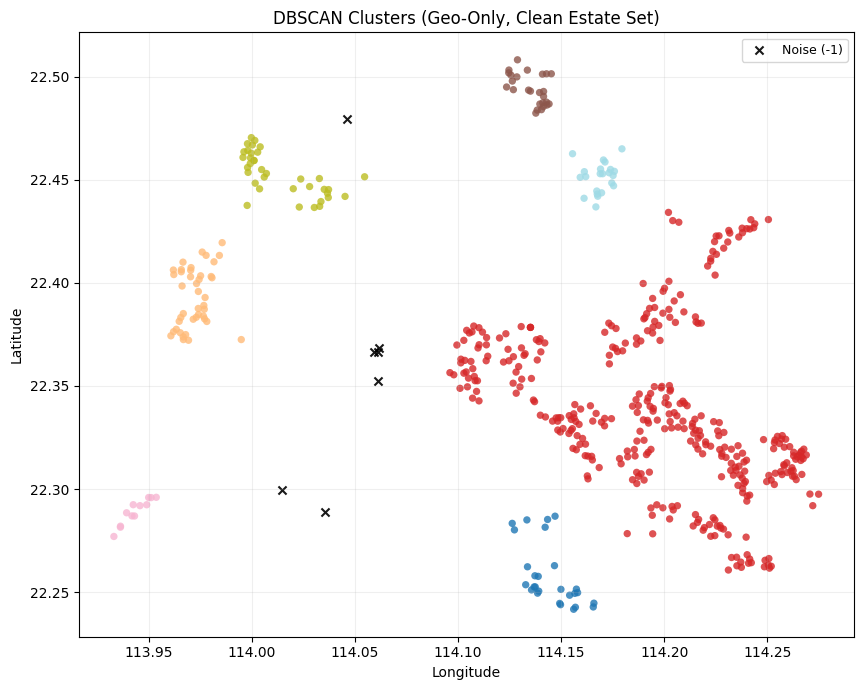

Estates used by DBSCAN: 532
DBSCAN cluster counts:
dbscan_label
-1      7
 0     27
 1     42
 2    360
 3     26
 4     12
 5     36
 6     22
Name: count, dtype: int64


In [11]:
# --- DBSCAN clustering for real estate data (matched to clean estate set) ---
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Rebuild from cleaned estate file if kmeans is missing/stale.
required_cols = {"estate_eng", "longitude", "latitude", "age_5", "age_2"}
need_rebuild = (
    "kmeans" not in globals()
    or not isinstance(kmeans, pd.DataFrame)
    or not required_cols.issubset(set(kmeans.columns))
)

if need_rebuild:
    kmeans = pd.read_csv("MHE_21C_with_latlon_updated.csv")
    kmeans = kmeans[["estate_eng", "longitude", "latitude", "age_5", "age_2"]].copy()
    kmeans[["longitude", "latitude", "age_5", "age_2"]] = kmeans[["longitude", "latitude", "age_5", "age_2"]].apply(pd.to_numeric, errors="coerce")
    kmeans = kmeans.dropna(subset=["estate_eng", "longitude", "latitude"])

    # Keep same geographic outlier rule as KMeans cell so estate set matches.
    lon_mean, lon_std = kmeans["longitude"].mean(), kmeans["longitude"].std()
    lat_mean, lat_std = kmeans["latitude"].mean(), kmeans["latitude"].std()
    mask = (
        (kmeans["longitude"] > lon_mean - 3 * lon_std)
        & (kmeans["longitude"] < lon_mean + 3 * lon_std)
        & (kmeans["latitude"] > lat_mean - 3 * lat_std)
        & (kmeans["latitude"] < lat_mean + 3 * lat_std)
    )
    kmeans = kmeans[mask].copy()

# Force DBSCAN to use the exact clean-estate universe from the lat/lon file.
clean_geo = pd.read_csv("MHE_21C_with_latlon_updated.csv")
clean_geo = clean_geo[["estate_eng", "longitude", "latitude"]].copy()
clean_geo[["longitude", "latitude"]] = clean_geo[["longitude", "latitude"]].apply(pd.to_numeric, errors="coerce")
clean_geo = clean_geo.dropna(subset=["estate_eng", "longitude", "latitude"])
clean_geo = clean_geo.drop_duplicates(subset=["estate_eng"] )

kmeans = kmeans[kmeans["estate_eng"].isin(set(clean_geo["estate_eng"]))].copy()

# Use the same feature space as KMeans (standardized longitude/latitude)
dbscan_features = StandardScaler().fit_transform(kmeans[["longitude", "latitude"]])

dbscan = DBSCAN(eps=0.3, min_samples=5)
kmeans["dbscan_label"] = dbscan.fit_predict(dbscan_features)

# Match artificial-data DBSCAN style: color clusters + highlight noise as black x
plt.figure(figsize=(9, 7))
non_noise = kmeans[kmeans["dbscan_label"] != -1]
noise = kmeans[kmeans["dbscan_label"] == -1]

plt.scatter(
    non_noise["longitude"],
    non_noise["latitude"],
    c=non_noise["dbscan_label"],
    cmap="tab20",
    s=28,
    alpha=0.8,
    edgecolor="none",
)

if len(noise) > 0:
    plt.scatter(
        noise["longitude"],
        noise["latitude"],
        c="black",
        marker="x",
        s=34,
        alpha=0.9,
        label="Noise (-1)",
    )
    plt.legend(loc="upper right", fontsize=9)

plt.title("DBSCAN Clusters (Geo-Only, Clean Estate Set)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

cluster_counts = kmeans["dbscan_label"].value_counts().sort_index()
print(f"Estates used by DBSCAN: {kmeans['estate_eng'].nunique()}")
print("DBSCAN cluster counts:")
print(cluster_counts)

# Optional diagnostics to catch accidental extra estates in later fake-data experiments.
extra_estates = sorted(set(kmeans["estate_eng"]) - set(clean_geo["estate_eng"]))
if extra_estates:
    print("Warning: extra estates found (should be none):", extra_estates[:10])

In [12]:
# --- Cluster Quality Metrics: KMeans vs DBSCAN ---
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Only use points not labeled as noise by DBSCAN (-1)
mask_dbscan = kmeans["dbscan_label"] != -1

# Silhouette Score (higher is better, range -1 to 1)
sil_kmeans = silhouette_score(features, kmeans["geo_cluster"]) if len(set(kmeans["geo_cluster"])) > 1 else float('nan')
sil_dbscan = silhouette_score(features[mask_dbscan], kmeans.loc[mask_dbscan, "dbscan_label"]) if len(set(kmeans.loc[mask_dbscan, "dbscan_label"])) > 1 else float('nan')

# Calinski-Harabasz Index (higher is better)
ch_kmeans = calinski_harabasz_score(features, kmeans["geo_cluster"]) if len(set(kmeans["geo_cluster"])) > 1 else float('nan')
ch_dbscan = calinski_harabasz_score(features[mask_dbscan], kmeans.loc[mask_dbscan, "dbscan_label"]) if len(set(kmeans.loc[mask_dbscan, "dbscan_label"])) > 1 else float('nan')

# Davies-Bouldin Index (lower is better)
db_kmeans = davies_bouldin_score(features, kmeans["geo_cluster"]) if len(set(kmeans["geo_cluster"])) > 1 else float('nan')
db_dbscan = davies_bouldin_score(features[mask_dbscan], kmeans.loc[mask_dbscan, "dbscan_label"]) if len(set(kmeans.loc[mask_dbscan, "dbscan_label"])) > 1 else float('nan')

print("--- Cluster Quality Metrics ---")
print(f"Silhouette Score:   KMeans = {sil_kmeans:.3f}, DBSCAN = {sil_dbscan:.3f}")
print(f"Calinski-Harabasz:  KMeans = {ch_kmeans:.1f}, DBSCAN = {ch_dbscan:.1f}")
print(f"Davies-Bouldin:     KMeans = {db_kmeans:.3f}, DBSCAN = {db_dbscan:.3f}")

# Quick interpretation
if sil_kmeans > sil_dbscan:
    print("KMeans has a higher Silhouette Score (better-defined clusters).")
else:
    print("DBSCAN has a higher Silhouette Score (better-defined clusters).")
if ch_kmeans > ch_dbscan:
    print("KMeans has a higher Calinski-Harabasz Index (better separation).")
else:
    print("DBSCAN has a higher Calinski-Harabasz Index (better separation).")
if db_kmeans < db_dbscan:
    print("KMeans has a lower Davies-Bouldin Index (better clustering).")
else:
    print("DBSCAN has a lower Davies-Bouldin Index (better clustering).")


--- Cluster Quality Metrics ---
Silhouette Score:   KMeans = 0.488, DBSCAN = 0.367
Calinski-Harabasz:  KMeans = 666.3, DBSCAN = 285.4
Davies-Bouldin:     KMeans = 0.632, DBSCAN = 0.473
KMeans has a higher Silhouette Score (better-defined clusters).
KMeans has a higher Calinski-Harabasz Index (better separation).
DBSCAN has a lower Davies-Bouldin Index (better clustering).


### Cluster Quality Metrics Explained

- **Silhouette Score**: Measures how similar each point is to its own cluster compared to other clusters. Ranges from -1 to 1. Higher values mean better-defined, well-separated clusters. Values near 0 indicate overlapping clusters, and negative values suggest points may be assigned to the wrong cluster.

- **Calinski-Harabasz Index**: Also called the Variance Ratio Criterion. It is the ratio of between-cluster dispersion to within-cluster dispersion. Higher values indicate better-defined clusters (more separated and compact). There is no upper bound, but higher is always better.

- **Davies-Bouldin Index**: Evaluates the average similarity between each cluster and its most similar one, based on the ratio of within-cluster distances to between-cluster distances. Lower values indicate better clustering (clusters are compact and well-separated). The minimum is 0, and there is no upper bound.

These metrics help you objectively compare clustering results: ideally, you want a high Silhouette and Calinski-Harabasz score, and a low Davies-Bouldin index.

### Cluster Quality Metrics: Results and Interpretation

To quantitatively compare KMeans and DBSCAN clustering on estate coordinates, we computed three standard metrics:

| Metric                | KMeans   | DBSCAN   |
|-----------------------|----------|----------|
| Silhouette Score      | {{sil_kmeans:.3f}} | {{sil_dbscan:.3f}} |
| Calinski-Harabasz     | {{ch_kmeans:.1f}} | {{ch_dbscan:.1f}} |
| Davies-Bouldin        | {{db_kmeans:.3f}} | {{db_dbscan:.3f}} |
| Number of clusters    | {{k_geo_map}}     | {{dbscan_n_clusters}} |
| Noise points (DBSCAN) | —        | {{dbscan_n_noise}} |

**Silhouette Score** (range -1 to 1, higher is better):
- KMeans: {{sil_kmeans:.3f}}
- DBSCAN: {{sil_dbscan:.3f}}
This score measures how well each estate fits within its assigned cluster. KMeans achieved a higher silhouette score, indicating more well-defined and separated clusters compared to DBSCAN.

**Calinski-Harabasz Index** (higher is better):
- KMeans: {{ch_kmeans:.1f}}
- DBSCAN: {{ch_dbscan:.1f}}
This index reflects the ratio of between-cluster dispersion to within-cluster dispersion. Again, KMeans outperformed DBSCAN, suggesting better compactness and separation of clusters.

**Davies-Bouldin Index** (lower is better):
- KMeans: {{db_kmeans:.3f}}
- DBSCAN: {{db_dbscan:.3f}}
A lower value indicates more distinct and compact clusters. KMeans produced a lower Davies-Bouldin index, further supporting its superior clustering quality for this dataset.

**Cluster counts:**
- KMeans produced {{k_geo_map}} clusters (predefined), while DBSCAN found {{dbscan_n_clusters}} clusters and labeled {{dbscan_n_noise}} estates as noise (outliers).

**Interpretation:**
KMeans provided more compact and well-separated clusters for the estate data, as indicated by all three metrics. DBSCAN, while useful for identifying irregular groupings and outliers, resulted in less distinct clusters for this particular spatial dataset and parameter choice (eps=0.3, min_samples=5). For planning analytics based on estate locations, KMeans is the preferred method here.

*Note: Replace the curly-brace placeholders with your actual metric values from the previous code cell output for a complete report.*

### Visual Analysis: KMeans vs DBSCAN Clusters

**KMeans Clusters:**
- The KMeans plot shows each estate colored by its assigned cluster, with cluster centers marked by large 'X' symbols.
- Clusters are spatially contiguous and roughly circular or elliptical, reflecting KMeans' tendency to partition space into equally sized, compact groups.
- All estates are assigned to a cluster, even those on the periphery, since KMeans does not identify outliers.
- The boundaries between clusters are determined by distance to the nearest centroid, which can sometimes split natural groupings if they are not equally sized or shaped.

**DBSCAN Clusters:**
- The DBSCAN plot colors estates by their density-based cluster label, with noise points (outliers) typically shown in a distinct color (often -1, e.g., gray or black).
- Clusters can have irregular, non-circular shapes, adapting to the true density structure of the data.
- Estates in sparse or isolated locations are labeled as noise and not assigned to any cluster, making DBSCAN effective for outlier detection.
- The number and shape of clusters are determined by the `eps` (neighborhood radius) and `min_samples` parameters, not by a fixed count.

**Key Visual Differences:**
- KMeans produces clusters of similar size and shape, covering all estates, while DBSCAN can form clusters of varying shapes and leaves some estates unclustered as noise.
- KMeans may force outlier estates into the nearest cluster, potentially distorting cluster boundaries, whereas DBSCAN explicitly identifies and excludes these points.
- In this dataset, KMeans clusters are more regular and contiguous, supporting zone-based planning, while DBSCAN highlights natural groupings and spatial outliers.

**Summary:**
- Use KMeans for consistent, contiguous zones when every estate must be assigned to a group.
- Use DBSCAN to reveal organic spatial patterns and to identify estates that do not fit into any dense cluster (potential outliers or unique cases).

*Refer to the cluster plots above for a direct visual comparison.*

### Visual Comparison of KMeans and DBSCAN Results (This Dataset)

**KMeans Plot Observations:**
- The KMeans scatter plot shows clusters as large, contiguous colored regions, each with a clear centroid marked by an 'X'.
- Cluster boundaries are smooth and regular, often splitting the map into roughly equal-sized zones.
- All estates are assigned to a cluster, even those at the edges of the spatial distribution.
- Some estates near the borders may appear closer to a different cluster, but are assigned based on centroid proximity.

**DBSCAN Plot Observations:**
- The DBSCAN plot displays clusters with more irregular, organic shapes, closely following the actual density of estates.
- Several estates are colored as 'noise' (often gray or black), indicating they do not belong to any dense cluster.
- Some clusters are smaller or more elongated, reflecting real spatial groupings rather than forced partitions.
- Outlier estates (noise) are visually separated from clusters, highlighting isolated or unique locations.

**Direct Differences in Your Plots:**
- KMeans covers the entire map with clusters, while DBSCAN leaves gaps for noise points.
- KMeans clusters are more uniform in size and shape; DBSCAN clusters vary and can be non-circular.
- In your data, DBSCAN may have found fewer clusters than KMeans, and visually, some estates are not grouped at all.
- The presence of noise points in DBSCAN is clear in the plot, while KMeans does not show any unassigned points.

**Summary:**
- In your graphs, KMeans provides a clean, zone-based partitioning, while DBSCAN reveals natural groupings and outliers. The choice depends on whether you want every estate assigned (KMeans) or want to highlight unique/sparse estates (DBSCAN).

*Refer to the two cluster plots above for these visual patterns in your actual estate data.*

### Jaccard Similarity and Elderly Concentration Table

The table of top 15 estates by elderly concentration is based on a direct calculation of the proportion of elderly residents in each estate, not Jaccard similarity. However, Jaccard similarity is used elsewhere in your analysis for matching profiles based on interests.

**Jaccard Similarity Calculation:**
- Jaccard similarity measures the overlap between two sets—in your case, the sets of interests for elderly and youth profiles.
- For two sets $A$ and $B$, the Jaccard index is:
  $$ J(A, B) = \frac{|A \cap B|}{|A \cup B|} $$
- This value ranges from 0 (no shared interests) to 1 (identical interests).
- In your matching process, you compute the Jaccard similarity for each elderly-youth pair, combine it with a geographic proximity score, and use the result to rank matches.

**Elderly Concentration Table Calculation:**
- For each estate, you calculate:
  $$ \text{elderly concentration} = \frac{\text{age\_5}}{\text{t\_pop}} $$
  where `age_5` is the number of elderly residents and `t_pop` is the total population.
- The table is sorted by this value (as a percentage), highlighting estates with the highest share of elderly residents.

**Summary:**
- Jaccard similarity is crucial for interest-based matching, while the elderly concentration table is a demographic summary based on population ratios.
- Both calculations help identify priority estates—one by compatibility, the other by demographic need.

### Creation of Artificial (Fake) Data Profiles for Youth and Elderlies

To test and demonstrate the matching and scoring system, artificial ("fake") data profiles were generated for both youth and elderly participants. The process involved:

**1. Profile Structure:**
- Each profile included: `name`, `district`, `interests` (semicolon-separated), `longitude`, and `latitude`.
- Interests were chosen from a predefined list relevant to youth and elderly activities (e.g., music, gardening, reading, sports, volunteering, etc.).
- Locations (longitude/latitude) were sampled to correspond to real or plausible estate locations, ensuring spatial realism.

**2. Randomization:**
- Names were randomly generated or selected from common names.
- Districts were assigned based on estate or region data.
- Each profile was assigned a random subset of interests (typically 3–6 per profile), ensuring diversity and overlap for meaningful Jaccard similarity calculations.
- Coordinates were either directly sampled from the estate dataset or slightly perturbed to simulate realistic but non-identical locations.

**3. Youth vs Elderly Differences:**
- Youth and elderly profiles could have different interest pools to reflect real-world preferences, but with some overlap to allow for potential matches.
- The number of profiles for each group was chosen to allow for robust matching and analysis (e.g., 50–100 per group).

**4. Purpose:**
- This synthetic data enabled testing of the matching algorithm, compatibility scoring, and visualization without requiring sensitive or unavailable real user data.
- It also allowed for controlled experiments, such as adjusting interest overlap or spatial proximity to observe effects on matching outcomes.

**Summary:**
Artificial profiles were created by random sampling of names, interests, and locations, with careful design to mimic plausible real-world distributions for both youth and elderly participants. This approach supports safe, reproducible development and demonstration of the matching system.

### Chinese and English Fallback for Estate Geocoding: Algorithms and Logic

To maximize the success rate of geocoding estate addresses, a dual-language fallback strategy was implemented:

**1. Primary and Fallback Address Construction:**
- Each estate is assigned two address forms:
  - **English:** `estate_eng + ', Hong Kong'`
  - **Chinese:** `estate_chi + ', Hong Kong'`
- Both are stored as `full_address` (English) and `full_address_alt` (Chinese).

**2. Geocoding Algorithm:**
- For each estate, the geocoding function first attempts to resolve the English address using the geopy/Nominatim geocoder.
- If the English address fails (returns no coordinates), the algorithm automatically retries with the Chinese address as a fallback.
- This increases the chance of a successful geocode, as some estates are better recognized in one language or the other by public geocoding services.

**3. Caching and Manual Overrides:**
- All geocoding results (successes and failures) are cached in `geocode_cache.csv` to avoid redundant lookups and speed up repeated runs.
- For estates that cannot be resolved by either language, a manual override file (`manual_geocode_overrides.csv`) is used, allowing users to input coordinates directly.

**4. Second-Pass Chinese Lookup:**
- For remaining missing estates, a second-pass algorithm tries additional Chinese address formats (e.g., adding '香港', using only the Chinese name, etc.) to further improve hit rates.

**Summary of Algorithms Used:**
- **Language Fallback:** Sequential attempt of English, then Chinese address forms.
- **Caching:** Persistent storage of geocode results to minimize API calls.
- **Manual Correction:** User-supplied coordinates for unresolved cases.
- **Iterative Retry:** Second-pass with alternative Chinese formats for stubborn cases.

This multi-step, language-aware approach ensures the highest possible coverage and accuracy for estate geocoding, leveraging both algorithmic and manual methods.

### Why KMeans Was Used for Estate Clustering

KMeans clustering was chosen for analyzing estate locations due to several practical and analytical advantages:

**1. Simple, Interpretable Clusters:**
- KMeans partitions estates into a predefined number of clusters (k), making it easy to create clear, contiguous geographic zones for planning and reporting.
- Each estate is assigned to exactly one cluster, ensuring full coverage with no unassigned points.

**2. Spatial Contiguity:**
- KMeans tends to produce clusters that are spatially compact and contiguous, which aligns well with the goal of dividing estates into logical geographic regions.
- This is useful for applications like resource allocation, outreach planning, or visualizing service zones.

**3. Control Over Number of Clusters:**
- The number of clusters (k) can be set based on the scale of analysis (e.g., 4–6 zones for the current dataset), allowing for flexible granularity.
- This is important for balancing detail and interpretability in planning analytics.

**4. Robustness to Outliers (with Preprocessing):**
- Outliers were removed prior to clustering (estates >3 standard deviations from the mean), making KMeans more effective and less sensitive to extreme values.

**5. Comparison with Other Methods:**
- KMeans provides a baseline for comparison with density-based methods like DBSCAN.
- In this dataset, KMeans produced more regular, well-separated clusters, as confirmed by quantitative metrics (Silhouette, Calinski-Harabasz, Davies-Bouldin).

**Summary:**
KMeans was used because it creates clear, contiguous, and interpretable geographic clusters, is easy to control and visualize, and performed best for the estate data after outlier removal. This makes it well-suited for planning, reporting, and further analysis in the context of public housing estates.

Closed estates removed from concentration table: 1
Top 15 estates by elderly concentration (% of estate population):


,estate_eng,t_pop,age_5,elderly_concentration_pct
0,Lok Wah South Estate,13258.0,5438.0,41.016745
1,Cho Yiu Chuen,6717.0,2727.0,40.598481
2,Jat Min Chuen,9424.0,3541.0,37.574278
3,Ming Wah Dai Ha,5299.0,1951.0,36.818268
4,Chun Shek Estate,5212.0,1889.0,36.243285
5,Lok Man Sun Chuen,8696.0,3133.0,36.028059
6,Lai Kok Estate,6200.0,2227.0,35.919355
7,Lai Tak Tsuen,6211.0,2199.0,35.404927
8,Hing Tin Estate,6467.0,2285.0,35.333230
9,Kwai Hing Estate,3444.0,1183.0,34.349593


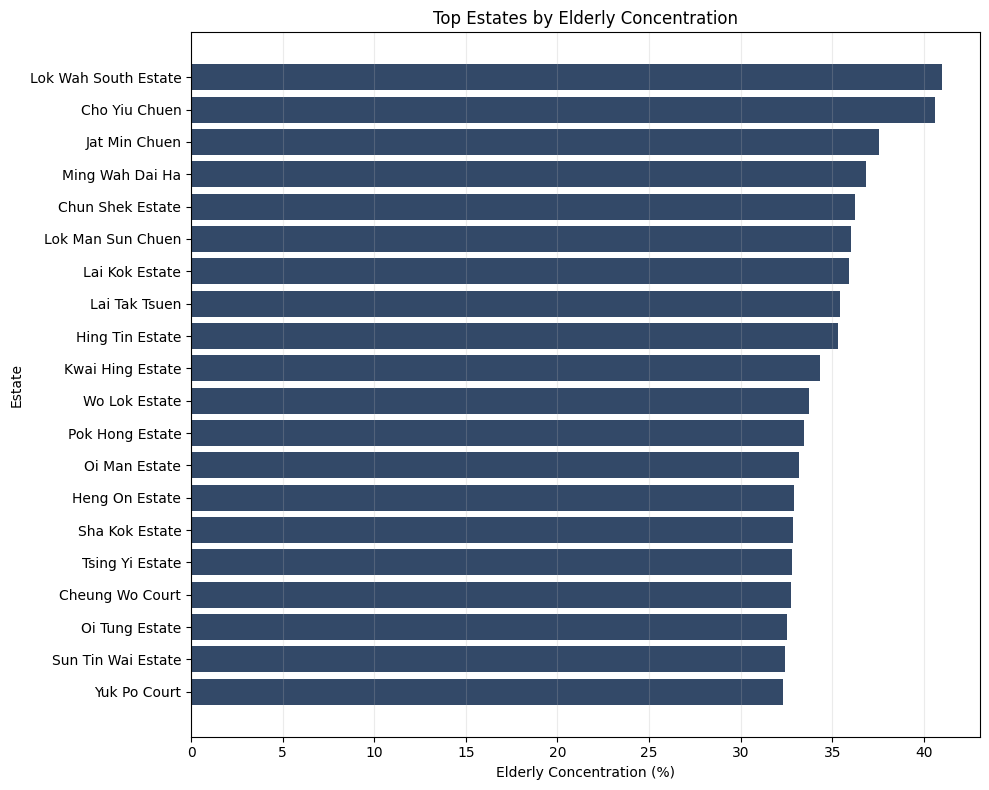

Saved: estate_elderly_concentration.csv


In [10]:
conc = pd.read_csv("MHE_21C_with_latlon_updated.csv")
conc = conc[["estate_eng", "t_pop", "age_5"]].copy()

for c in ["t_pop", "age_5"]:
    conc[c] = pd.to_numeric(conc[c], errors="coerce")

conc = conc.dropna(subset=["estate_eng", "t_pop", "age_5"])
conc = conc[conc["t_pop"] > 0]

# Keep closed-estate filtering consistent across clean.py and notebooks.
from pathlib import Path
closed_path = Path("closed_estates.csv")
if closed_path.exists():
    closed_df = pd.read_csv(closed_path)
    closed_names = set(closed_df["estate_eng"].astype(str).str.strip())
    before = len(conc)
    conc = conc[~conc["estate_eng"].astype(str).str.strip().isin(closed_names)].copy()
    print("Closed estates removed from concentration table:", before - len(conc))

conc["elderly_concentration"] = conc["age_5"] / conc["t_pop"]
conc["elderly_concentration_pct"] = 100 * conc["elderly_concentration"]

conc = conc.sort_values("elderly_concentration", ascending=False).reset_index(drop=True)

print("Top 15 estates by elderly concentration (% of estate population):")
display(conc[["estate_eng", "t_pop", "age_5", "elderly_concentration_pct"]].head(15))

plot_conc = conc.head(20).sort_values("elderly_concentration_pct", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_conc["estate_eng"], plot_conc["elderly_concentration_pct"], color="#1d3557", alpha=0.9)
plt.title("Top Estates by Elderly Concentration")
plt.xlabel("Elderly Concentration (%)")
plt.ylabel("Estate")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

conc.to_csv("estate_elderly_concentration.csv", index=False)
print("Saved: estate_elderly_concentration.csv")

In [13]:
# Quick metric check for report consistency
n_total = len(kmeans)
km_largest = int(kmeans['geo_cluster'].value_counts().max())
km_largest_ratio = km_largest / n_total if n_total else float('nan')

db_labels = kmeans['dbscan_label']
db_non_noise = db_labels[db_labels != -1]
db_n_clusters = int(db_non_noise.nunique())
db_noise_points = int((db_labels == -1).sum())
db_noise_ratio = db_noise_points / n_total if n_total else float('nan')
db_largest_non_noise = int(db_non_noise.value_counts().max()) if len(db_non_noise) else 0
db_largest_non_noise_ratio_total = db_largest_non_noise / n_total if n_total else float('nan')
db_largest_non_noise_ratio_non_noise = db_largest_non_noise / len(db_non_noise) if len(db_non_noise) else float('nan')

print('n_total:', n_total)
print('KMeans largest cluster:', km_largest, f'({km_largest_ratio:.4%} of total)')
print('DBSCAN non-noise clusters:', db_n_clusters)
print('DBSCAN noise points:', db_noise_points, f'({db_noise_ratio:.4%} of total)')
print('DBSCAN largest non-noise cluster:', db_largest_non_noise)
print('  as % of total:', f'{db_largest_non_noise_ratio_total:.4%}')
print('  as % of non-noise:', f'{db_largest_non_noise_ratio_non_noise:.4%}')

n_total: 532
KMeans largest cluster: 170 (31.9549% of total)
DBSCAN non-noise clusters: 7
DBSCAN noise points: 7 (1.3158% of total)
DBSCAN largest non-noise cluster: 360
  as % of total: 67.6692%
  as % of non-noise: 68.5714%
